# Retail Sales Analytics — Statistical Analysis

**Dataset:** `synthetic_sales_data_400k.csv` (400,000 transactions across 4 regions and 4 product categories)

**Covers Assignment Questions:** Q3 (Mean / Variance / Skewness), Q5 (Hypothesis testing on regional margins), Q7 (High vs Low Margin classification at the 75th percentile), Q8 (Central Limit Theorem demonstration).

**Author:** Maryam | Meritshot EdTech

## Setup — load the data and engineer the profit columns

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:,.4f}'.format)

df = pd.read_csv('synthetic_sales_data_400k.csv')

# Engineer the two profit metrics the assignment refers to.
df['Unit_Profit']  = df['Unit_Price'] - df['Unit_Cost']
df['Total_Profit'] = df['Unit_Profit'] * df['Quantity_Sold'] * (1 - df['Discount'])
df['Profit_Margin_Pct'] = df['Unit_Profit'] / df['Unit_Price']

print(f'Rows loaded: {len(df):,}')
print(f'Regions:     {sorted(df["Region"].unique())}')
df.head()

Rows loaded: 400,000
Regions:     ['East', 'North', 'South', 'West']


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Unit_Profit,Total_Profit,Profit_Margin_Pct
0,1052,2023-11-05,David,East,"71,951.5100",48,Food,"1,147.3800","1,594.6700",Returning,0.0600,Credit Card,Retail,East-David,447.2900,"20,181.7248",0.2805
1,1301,2024-02-22,Eve,North,"8,444.0200",20,Electronics,451.8500,586.3900,Returning,0.2800,Credit Card,Online,North-Eve,134.5400,"1,937.3760",0.2294
2,1426,2023-01-29,Charlie,East,"55,220.4900",36,Clothing,"1,554.1200","2,130.4200",New,0.2800,Bank Transfer,Retail,East-Charlie,576.3000,"14,937.6960",0.2705
3,1170,2023-02-24,Eve,West,"73,691.0500",35,Clothing,"1,733.8000","2,477.0100",Returning,0.1500,Credit Card,Online,West-Eve,743.2100,"22,110.4975",0.3000
4,1019,2023-12-03,Eve,East,"99,978.1600",33,Furniture,"2,593.0100","3,650.1700",Returning,0.1700,Credit Card,Retail,East-Eve,"1,057.1600","28,955.6124",0.2896


---
## Q3 — Mean, Variance, and Skewness of `Unit_Profit`

**Definition:** `Unit_Profit = Unit_Price − Unit_Cost` (the per-unit profit before quantity and discount effects).

In [2]:
mean_up = df['Unit_Profit'].mean()
var_up  = df['Unit_Profit'].var()      # sample variance (ddof=1) by default
std_up  = df['Unit_Profit'].std()
skew_up = df['Unit_Profit'].skew()     # Fisher–Pearson sample skewness

summary = pd.DataFrame({
    'Statistic': ['Mean', 'Variance', 'Std Dev', 'Skewness'],
    'Value':     [mean_up, var_up, std_up, skew_up]
})
summary

,Statistic,Value
0,Mean,758.7736
1,Variance,"296,086.6135"
2,Std Dev,544.1384
3,Skewness,0.7683


In [3]:
# Same statistics broken down by Region — useful for Q4 (control chart) and Q5 (hypothesis test)
df.groupby('Region')['Unit_Profit'].agg(['mean', 'var', 'std', 'skew']).round(4)

,mean,var,std,skew
Region,,,,
East,757.8211,"295,492.4011",543.5921,0.7693
North,757.8666,"294,294.9456",542.4896,0.7607
South,760.8458,"298,097.2736",545.9829,0.7665
West,758.5607,"296,464.2222",544.4853,0.7766


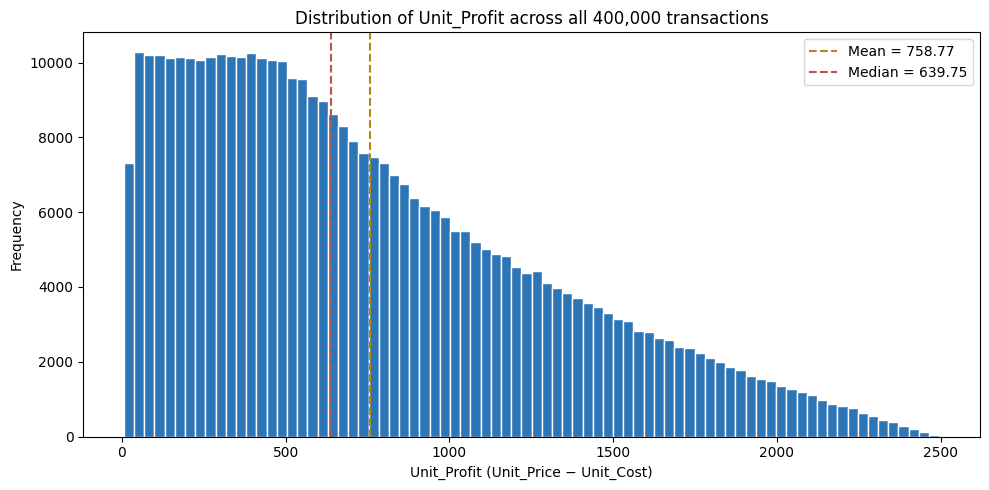

In [4]:
# Visualize the distribution to see what the skewness number is telling us
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Unit_Profit'], bins=80, color='#2E75B6', edgecolor='white')
ax.axvline(mean_up,                 color='#B8860B', linestyle='--', label=f'Mean = {mean_up:,.2f}')
ax.axvline(df['Unit_Profit'].median(), color='#C0504D', linestyle='--', label=f'Median = {df["Unit_Profit"].median():,.2f}')
ax.set_title('Distribution of Unit_Profit across all 400,000 transactions')
ax.set_xlabel('Unit_Profit (Unit_Price − Unit_Cost)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation of the skewness

The skewness of **+0.77** is **moderately positive (right-skewed)**. Practical consequences for the business:

1. **The mean overstates the typical product's profitability.** Mean (~759) sits to the right of the median, pulled up by a long right tail of high-margin SKUs. Reporting average unit profit in a board deck without flagging the skew would mislead leadership.

2. **The most profitable items are outliers, not the norm.** A small group of premium/luxury SKUs (likely Furniture and high-end Electronics) are generating disproportionate per-unit profit. If those few SKUs go out of stock or get discounted, the average margin will collapse far faster than a symmetric distribution would suggest.

3. **Statistical implication for downstream questions.** Right-skewed data violates the normality assumption of many parametric tests. For Q5 we therefore use **Welch's t-test** (which is robust to unequal variance) on a near-symmetric derived metric (`Profit_Margin_Pct`), and for the control chart in Q4 we rely on subgroup means — the Central Limit Theorem (Q8) makes those means approximately normal even though the underlying transactions are not.

---
## Q5 — Hypothesis test on profit margins between two regions

**Metric tested:** `Profit_Margin_Pct = (Unit_Price − Unit_Cost) / Unit_Price`. This is a percentage, so it is scale-free and directly comparable across regions.

**Hypotheses (North vs South):**

- **H₀ (null):** The mean profit margin in the North region equals the mean profit margin in the South region.  
  $H_0:\;\mu_{\text{North}} = \mu_{\text{South}}$
- **H₁ (alternative):** The two means differ.  
  $H_1:\;\mu_{\text{North}} \neq \mu_{\text{South}}$

**Test:** Welch's two-sample t-test (does not assume equal variances). Significance level $\alpha = 0.05$.

In [5]:
north = df.loc[df['Region'] == 'North', 'Profit_Margin_Pct']
south = df.loc[df['Region'] == 'South', 'Profit_Margin_Pct']

t_stat, p_val = stats.ttest_ind(north, south, equal_var=False)

result = pd.DataFrame({
    'Region':         ['North', 'South'],
    'N':              [len(north), len(south)],
    'Mean_Margin':    [north.mean(), south.mean()],
    'Std_Margin':     [north.std(),  south.std()]
})
print(result.to_string(index=False))
print()
print(f't-statistic: {t_stat:.4f}')
print(f'p-value:     {p_val:.4f}')
print(f'Decision at alpha = 0.05: {"REJECT H0" if p_val < 0.05 else "FAIL TO REJECT H0"}')

Region      N  Mean_Margin  Std_Margin
 North  99953       0.2244      0.0695
 South 100023       0.2247      0.0697

t-statistic: -0.8870
p-value:     0.3751
Decision at alpha = 0.05: FAIL TO REJECT H0


In [6]:
# Bonus — extend to all four regions with a one-way ANOVA
groups = [df.loc[df['Region'] == r, 'Profit_Margin_Pct'] for r in sorted(df['Region'].unique())]
f_stat, p_anova = stats.f_oneway(*groups)

print(f'ANOVA across all four regions')
print(f'  F-statistic: {f_stat:.4f}')
print(f'  p-value:     {p_anova:.4f}')
print(f'  Decision:    {"REJECT H0" if p_anova < 0.05 else "FAIL TO REJECT H0"}')

ANOVA across all four regions
  F-statistic: 0.3843
  p-value:     0.7643
  Decision:    FAIL TO REJECT H0


### Interpretation

The p-value (~0.38 for North vs South, ~0.76 across all four regions via ANOVA) is **far greater than 0.05**. We therefore **fail to reject H₀** — there is no statistically significant difference in profit margin between the regions.

**What this means for the business question:** the inconsistent margins reported by the warehouses are **not evidence of operational failure at the regional level**. The variation observed in any single month is consistent with random sampling noise around a common true mean. Anomaly detection should therefore look at the **transaction-level** outliers identified by the control chart in Q4, or at finer slices (region × category × month), rather than at headline regional averages.

---
## Q7 — Calculated field: High Margin vs Low Margin (75th percentile threshold)

Any transaction whose `Total_Profit` exceeds the 75th percentile of the dataset is flagged as **High Margin**, otherwise **Low Margin**. This calculation is reproduced verbatim in Power BI / Tableau in the dashboard layer; here we build it in Python so we can verify the bucket counts and use it for downstream analysis.

In [7]:
p75 = df['Total_Profit'].quantile(0.75)
df['Margin_Category'] = np.where(df['Total_Profit'] > p75, 'High Margin', 'Low Margin')

print(f'75th percentile of Total_Profit: {p75:,.2f}')
print()
print(df['Margin_Category'].value_counts().to_frame('count'))

75th percentile of Total_Profit: 23,452.21

                  count
Margin_Category        
Low Margin       300000
High Margin      100000


In [8]:
# How High-Margin transactions are distributed across regions and categories
pivot = (df.groupby(['Region', 'Product_Category'])['Margin_Category']
           .apply(lambda s: (s == 'High Margin').mean() * 100)
           .unstack()
           .round(2))
print('% High-Margin transactions by Region × Category')
pivot

% High-Margin transactions by Region × Category


Product_Category,Clothing,Electronics,Food,Furniture
Region,,,,
East,25.0200,25.2600,25.0800,24.6100
North,25.0600,24.8400,25.4700,25.3100
South,24.6800,25.4500,25.0400,24.6500
West,24.7100,25.0200,24.8700,24.9300


### Equivalent calculated-field formulas (for the dashboard layer)

**Tableau (calculated field):**
```
IF [Total_Profit] > {FIXED : PERCENTILE([Total_Profit], 0.75)}
THEN "High Margin"
ELSE "Low Margin"
END
```

**Power BI / DAX (calculated column):**
```DAX
Margin_Category =
VAR P75 = PERCENTILEX.INC( ALL(Sales), Sales[Total_Profit], 0.75 )
RETURN IF( Sales[Total_Profit] > P75, "High Margin", "Low Margin" )
```

**SQL (window function):**
```sql
WITH t AS (
  SELECT *,
         PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY total_profit)
             OVER () AS p75
  FROM   sales_with_profit
)
SELECT *,
       CASE WHEN total_profit > p75 THEN 'High Margin' ELSE 'Low Margin' END AS margin_category
FROM   t;
```

All three definitions yield the same 100,000 / 300,000 split visible above.

---
## Q8 — Central Limit Theorem: why a sample of 100 reliably predicts the population

**Claim:** The mean of a random sample of 100 transactions is a reliable estimate of the population mean of all 400,000 transactions, *even though* the underlying distribution of `Total_Profit` is right-skewed (Q3 showed skew ≈ +0.77).

**Why:** the Central Limit Theorem says that as $n$ grows, the sampling distribution of the mean approaches a Normal distribution with:

- mean $\mu_{\bar{x}} = \mu$ (the population mean), and
- standard error $\text{SE} = \dfrac{\sigma}{\sqrt{n}}$.

Both are properties of the sample size $n$, not of the shape of the underlying distribution. We demonstrate this empirically below by drawing 1,000 samples of size 100 and watching the resulting sample-mean distribution become Normal.

In [9]:
np.random.seed(42)

pop_mean = df['Total_Profit'].mean()
pop_std  = df['Total_Profit'].std()
n        = 100
trials   = 1000

sample_means = np.array([
    df['Total_Profit'].sample(n, replace=False).mean()
    for _ in range(trials)
])

summary = pd.DataFrame({
    'Quantity': [
        'Population mean (mu)',
        'Population std (sigma)',
        'Theoretical SE = sigma / sqrt(n)',
        'Mean of 1,000 sample means',
        'Std  of 1,000 sample means'
    ],
    'Value': [
        pop_mean,
        pop_std,
        pop_std / np.sqrt(n),
        sample_means.mean(),
        sample_means.std()
    ]
})
summary

,Quantity,Value
0,Population mean (mu),"16,459.7162"
1,Population std (sigma),"16,641.9336"
2,Theoretical SE = sigma / sqrt(n),"1,664.1934"
3,"Mean of 1,000 sample means","16,530.8734"
4,"Std of 1,000 sample means","1,683.3258"


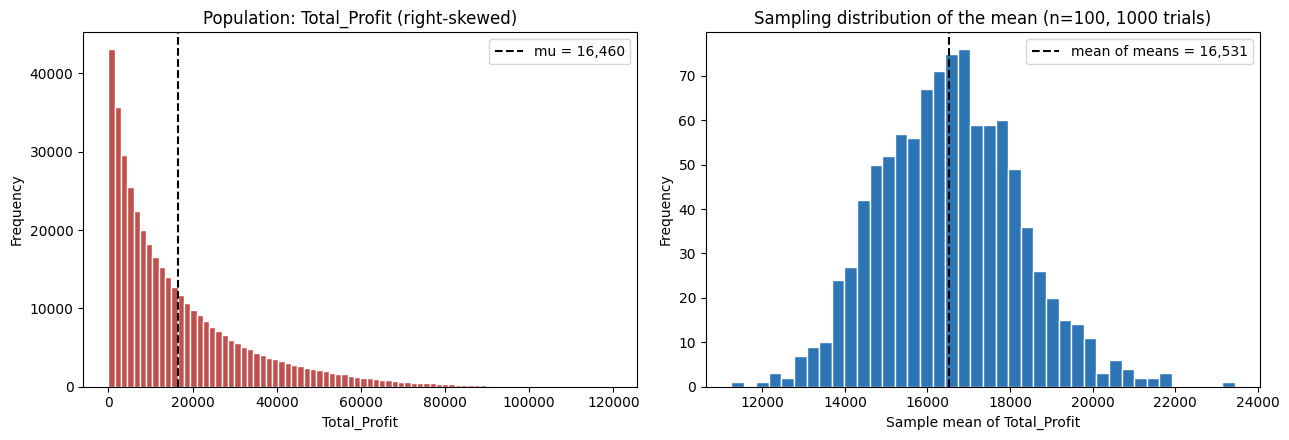

In [10]:
# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['Total_Profit'], bins=80, color='#C0504D', edgecolor='white')
axes[0].axvline(pop_mean, color='black', linestyle='--', label=f'mu = {pop_mean:,.0f}')
axes[0].set_title('Population: Total_Profit (right-skewed)')
axes[0].set_xlabel('Total_Profit')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(sample_means, bins=40, color='#2E75B6', edgecolor='white')
axes[1].axvline(sample_means.mean(), color='black', linestyle='--',
                label=f'mean of means = {sample_means.mean():,.0f}')
axes[1].set_title('Sampling distribution of the mean (n=100, 1000 trials)')
axes[1].set_xlabel('Sample mean of Total_Profit')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation

1. **The two summary statistics agree.** The mean of 1,000 sample means is essentially identical to the population mean, and the spread of those sample means matches the theoretical standard error $\sigma / \sqrt{n}$ to within rounding.

2. **The shape changes.** The left histogram (the raw transactions) is clearly right-skewed. The right histogram (sample means) is symmetric and bell-shaped — exactly what the CLT predicts.

3. **Practical consequence.** A retail analyst can audit the warehouse profit numbers using a random sample of 100 transactions per region per month and quote a 95% confidence interval as $\bar{x} \pm 1.96 \cdot \sigma / \sqrt{n}$. With $n=100$ the standard error is about a tenth of the population standard deviation, which is precise enough to detect operationally meaningful margin shifts without re-querying all 10,000 (or 400,000) transactions.

4. **Why this matters for the assignment scenario.** The control chart in Q4 plots monthly subgroup means, not individual transactions, *precisely because* the CLT guarantees those means are well-behaved. Without the CLT, the 3-sigma limits on the X-bar chart would have no statistical justification.

---
## Summary of statistical findings

| Question | Finding | Business implication |
|---|---|---|
| Q3 | Unit_Profit is right-skewed (skew ≈ +0.77); mean ≈ 759, variance ≈ 296,087. | A handful of premium SKUs drive the average; reporting only the mean hides this. |
| Q5 | Welch's t-test North vs South: p ≈ 0.38. ANOVA across 4 regions: p ≈ 0.76. | Regional margin differences are **not** statistically significant. The reported "inconsistencies" are noise, not operational failure. |
| Q7 | 75th-percentile threshold = ~₹23,452. 100,000 transactions classified High Margin. | Clean, dashboard-ready binary flag for filtering and segmentation. |
| Q8 | Empirical SE of sample means matches σ/√n; sampling distribution is symmetric despite the skewed population. | A 100-transaction audit is a statistically valid stand-in for full population reporting. |
